# Tâche #3 : Classification d'incidents avec des modèles *Transformers*

On reprend le thème de la classification de descriptions d’incidents. Utilisez la librairie *HuggingFace* pour accomplir cette tâche. On vous demande plus spécifiquement d’utiliser 2 modèles : le modèle *bert-base-uncased* et un autre modèle de votre choix. Débutez votre travail à partir de ce notebook.

Le corpus de textes contient 3 partitions :

-	*data/incidents_train.json* : fichier d’entraînement
-	*data/incidents_dev.json* : fichier de validation
-	*data/incidents_test.json* : fichier de test

Vous pouvez ajouter au *notebook* toutes les cellules dont vous avez besoin pour votre code, vos explications ou la présentation de vos résultats. Vous pouvez également ajouter des sous-sections (par ex. des sous-sections 4.1, 4.2 etc.) si cela améliore la lisibilité.

## 1. Création du jeu de données (*les 3 partitions du dataset*)

In [ ]:
#import json

#def load_json_data(filename):
    #with open(filename, 'r') as fp:
        #data = json.load(fp)
    #return data

In [1]:
from google.colab import files
import os

os.makedirs("data", exist_ok=True)
os.chdir("data")
uploaded = files.upload()
os.chdir("..")

Saving incidents_test.json to incidents_test (1).json
Saving incidents_dev.json to incidents_dev (1).json
Saving incidents_train.json to incidents_train (1).json


In [2]:
from datasets import load_dataset

# On va chercher les fichiers json et on les transforme en dataset HugginFace
raw_datasets = load_dataset("json", data_files={
    "train": "data/incidents_train.json",
    "validation": "data/incidents_dev.json",
    "test": "data/incidents_test.json"
})

# On a besoin de cast les label en int parce que sinon en entraînant sur les données,
# on se retrouve avec une erreur (ils sont en str dans les fichiers).
def cast_label(label):
    label["label"] = int(label["label"])
    return label
raw_datasets = raw_datasets.map(cast_label)

Map:   0%|          | 0/2475 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

# On va chercher le tokenizer de BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

# On sépare notre dataset selon les différents fichiers
train_dataset = tokenized_datasets["train"]
dev_dataset = tokenized_datasets["validation"]
test_dataset = tokenized_datasets["test"]
test_labels = test_dataset["label"]

Map:   0%|          | 0/2475 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# On va chercher le tokenizer d'Electra
def tokenize_function_electra(examples):
    return tokenizer_electra(examples["text"], truncation=True, padding=True)

tokenizer_electra = AutoTokenizer.from_pretrained("google/electra-base-discriminator")

tokenized_datasets_electra = raw_datasets.map(tokenize_function_electra, batched=True)

# On sépare notre dataset selon les différents fichiers
train_dataset_electra = tokenized_datasets_electra["train"]
dev_dataset_electra = tokenized_datasets_electra["validation"]
test_dataset_electra = tokenized_datasets_electra["test"]
test_labels_electra = test_dataset_electra["label"]

Map:   0%|          | 0/2475 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

Map:   0%|          | 0/531 [00:00<?, ? examples/s]

## 2. Création des 2 modèles

### 2.1 Modèle BERT


In [5]:
num_classes = len(set(train_dataset["label"]))

# Création du modèle BERT
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_classes)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 2.2 Deuxième modèle


In [6]:
from transformers import ElectraForPreTraining, ElectraTokenizerFast

# Création du modèle Electra
electra_model = AutoModelForSequenceClassification.from_pretrained("google/electra-base-discriminator", num_labels=num_classes)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

In [7]:
# On crée un autre modèle pour notre deuxième test
model_electra_v2 = AutoModelForSequenceClassification.from_pretrained(
    "google/electra-base-discriminator",
    num_labels=num_classes
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

In [8]:
# Un crée un troisième modèle pour notre troisième test
model_electra_v3 = AutoModelForSequenceClassification.from_pretrained(
    "google/electra-base-discriminator",
    num_labels=num_classes
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
electra.embeddings_project.bias                   | UNEXPECTED | 
electra.embeddings_project.weight                 | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

## 3. Entraînement des 2 modèles

### 3.1 Modèle BERT


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# On doit choisir les arguments lors de l'entraînement du modèle
# Ce sont les paramètres par "défauts" choisi pour les premiers tests
training_args = TrainingArguments(
    output_dir="./resutlats_bert",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset = train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
)

trainer.train()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


### 3.2 Deuxième modèle


In [13]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
# On entraîne notre modèle electra avec les mêmes paramètres par défaut
training_args_electra = TrainingArguments(
    output_dir="./resutlats_electra",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer_electra = Trainer(
    model=electra_model,
    args=training_args_electra,
    train_dataset = train_dataset_electra,
    eval_dataset=dev_dataset_electra,
    processing_class=tokenizer_electra,
)

trainer_electra.train()

Epoch,Training Loss,Validation Loss
1,No log,1.003906
2,1.156154,0.902117
3,1.156154,0.780701


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=930, training_loss=0.9519264795446909, metrics={'train_runtime': 947.7946, 'train_samples_per_second': 7.834, 'train_steps_per_second': 0.981, 'total_flos': 1953722370124800.0, 'train_loss': 0.9519264795446909, 'epoch': 3.0})

In [20]:
# Pour le deuxième test on change le learning_rate à 1e-4 pour observer les différences
training_args_electra_v2 = TrainingArguments(
    output_dir="./resultats_electra_v2",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer_electra_v2 = Trainer(
    model=model_electra_v2,
    args=training_args_electra_v2,
    train_dataset=train_dataset_electra,
    eval_dataset=dev_dataset_electra,
    processing_class=tokenizer_electra,
)

trainer_electra_v2.train()

Epoch,Training Loss,Validation Loss
1,No log,1.135440
2,1.222298,1.130981
3,1.222298,1.012079


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=930, training_loss=1.1422289448399698, metrics={'train_runtime': 847.2822, 'train_samples_per_second': 8.763, 'train_steps_per_second': 1.098, 'total_flos': 1953722370124800.0, 'train_loss': 1.1422289448399698, 'epoch': 3.0})

In [2]:
# Troisième test on change le epochs à 6 pour voir si le loss validation descends, se stabilise ou remonte
training_args_electra_v3 = TrainingArguments(
    output_dir="./resultats_electra_v3",
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer_electra_v3 = Trainer(
    model=model_electra_v3,
    args=training_args_electra_v3,
    train_dataset=train_dataset_electra,
    eval_dataset=dev_dataset_electra,
    processing_class=tokenizer_electra,
)

trainer_electra_v3.train()

NameError: name 'TrainingArguments' is not defined

## 4. Évaluation et résultats

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fonction pour afficher la matrice de confusion
def display_confusion_matrix(confusion_matrix, classes):
  print("\n\nVersion graphique de la matrice de confusion")
  df_cm = pd.DataFrame(confusion_matrix, index=classes, columns=classes)
  f, ax = plt.subplots(figsize=(7,5))
  sns.heatmap(df_cm, annot=True, fmt="d", linewidths=.5, ax=ax)
  plt.show()




Évaluation sur les données de test sur BERT
 Exactitude =  0.7890772128060264
 Macro rappel recall) =  0.7241322309903088
Macro précision =  0.7581699480080274

Matrice de confusion
 [[ 75   0   0   0   0   7   1   9  11]
 [  0   5   0   0   0   0   0   2   0]
 [  0   0  57   0   0   1   0   0   0]
 [  3   1   0  11   0   0   0   0   0]
 [  0   0   0   0   1   0   0   1   0]
 [  6   0   1   0   0 180   0   2   2]
 [  0   0   1   1   0   0  26   1   0]
 [ 19   0   4   1   1   4   0  31   6]
 [ 14   0   0   0   0   7   0   6  33]]


Version graphique de la matrice de confusion


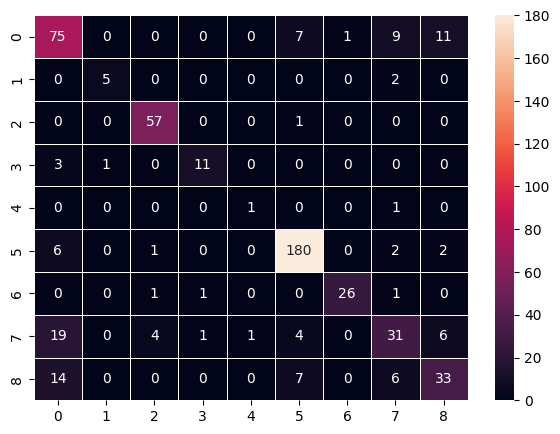

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

# On affiche les données exactitude, rappel et précision pour BERT
print("\nÉvaluation sur les données de test sur BERT")
print(" Exactitude = ", accuracy_score(test_labels, preds))
print(" Macro rappel recall = ", recall_score(test_labels, preds, average="macro"))
print( "Macro précision = ", precision_score(test_labels, preds, average = "macro"))

cm = confusion_matrix(test_labels, preds)
print("\nMatrice de confusion\n", cm)

classes = sorted(set(test_labels))
display_confusion_matrix(cm, classes)


Évaluation sur les données de test (ELECTRA)
 Exactitude =  0.736346516007533
 Macro rappel (recall) =  0.5032539919828992


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Macro précision =  0.5033292247439956

Matrice de confusion
 [[ 72   0   0   0   0   9   2  13   7]
 [  0   0   0   2   0   0   1   4   0]
 [  0   0  57   0   0   1   0   0   0]
 [  2   0   0   4   0   0   7   2   0]
 [  0   0   0   1   0   1   0   0   0]
 [  6   0   1   0   0 182   0   1   1]
 [  0   0   5   0   0   1  23   0   0]
 [ 17   0   4   2   0   4   3  32   4]
 [ 15   0   0   1   0   8   0  15  21]]


Version graphique de la matrice de confusion


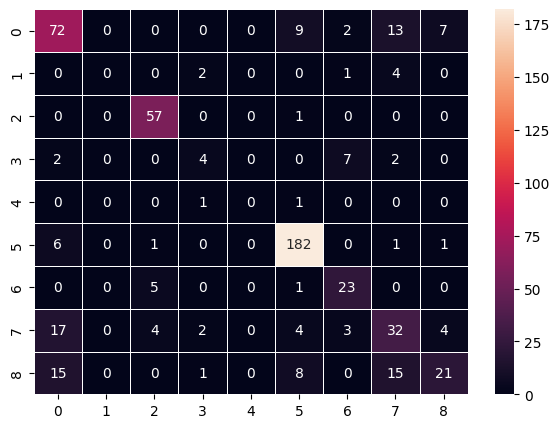

In [19]:
# Avec le Deuxième modèle

# On affiche les données exactitude, rappel et précision pour Electra

predictions_electra = trainer_electra.predict(test_dataset_electra)
preds_electra = np.argmax(predictions_electra.predictions, axis=1)

print("\nÉvaluation sur les données de test (ELECTRA)")
print(" Exactitude = ", accuracy_score(test_labels_electra, preds_electra))
print(" Macro rappel (recall) = ", recall_score(test_labels_electra, preds_electra, average="macro"))
print(" Macro précision = ", precision_score(test_labels_electra, preds_electra, average="macro"))

cm_electra = confusion_matrix(test_labels_electra, preds_electra)
print("\nMatrice de confusion\n", cm_electra)

classes_electra = sorted(set(test_labels_electra))
display_confusion_matrix(cm_electra, classes_electra)






Évaluation sur les données de test ELECTRA V2 avec le learning_rate ajusté
 Exactitude =  0.608286252354049
 Macro rappel (recall) =  0.36192792709978
 Macro précision =  0.3079818914978991


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Matrice de confusion
 [[ 75   0   0   0   0  13   3   0  12]
 [  5   0   0   0   0   2   0   0   0]
 [  0   0  52   0   0   2   4   0   0]
 [  9   0   0   0   0   1   4   0   1]
 [  1   0   0   0   0   1   0   0   0]
 [ 10   0   0   0   0 171   0   0  10]
 [  3   0   5   0   0   2  18   0   1]
 [ 48   0   3   0   0   4   4   0   7]
 [ 33   0   0   0   0  18   2   0   7]]


Version graphique de la matrice de confusion


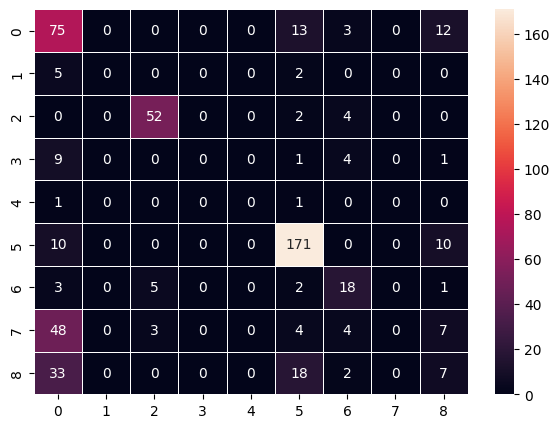

In [21]:
# On affiche les données exactitude, rappel et précision pour Electra
# On observe les données du deuxième test

predictions_electra_v2 = trainer_electra_v2.predict(test_dataset_electra)
preds_electra_v2 = np.argmax(predictions_electra_v2.predictions, axis=1)

print("\nÉvaluation sur les données de test ELECTRA V2 avec le learning_rate ajusté")
print(" Exactitude = ", accuracy_score(test_labels_electra, preds_electra_v2))
print(" Macro rappel (recall) = ", recall_score(test_labels_electra, preds_electra_v2, average="macro"))
print(" Macro précision = ", precision_score(test_labels_electra, preds_electra_v2, average="macro"))

cm_electra_v2 = confusion_matrix(test_labels_electra, preds_electra_v2)
print("\nMatrice de confusion\n", cm_electra_v2)

classes_electra_v2 = sorted(set(test_labels_electra))
display_confusion_matrix(cm_electra_v2, classes_electra_v2)


Évaluation sur les données de test (ELECTRA v3 - epoch)
 Accuracy =  0.7532956685499058
 Macro rappel (recall) =  0.6543167182312905
 Macro précision =  0.6782687841827628

Matrice de confusion
 [[ 64   0   0   0   0   6   1  13  19]
 [  0   6   0   0   0   0   0   1   0]
 [  0   0  56   0   0   1   1   0   0]
 [  2   0   0  10   0   0   0   2   1]
 [  0   0   0   0   0   1   0   1   0]
 [  7   0   1   0   0 177   0   1   5]
 [  0   0   1   1   0   0  25   2   0]
 [ 14   0   4   2   0   5   0  29  12]
 [ 12   0   0   0   0   8   1   6  33]]


Version graphique de la matrice de confusion


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


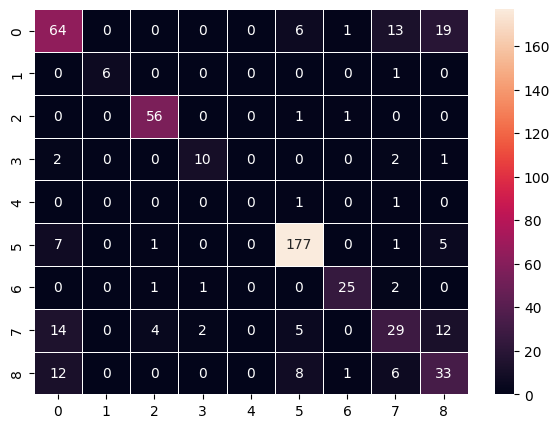

In [16]:
# On affiche les données exactitude, rappel et précision pour Electra
# On observe les données du troisième test
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
predictions_electra_v3 = trainer_electra_v3.predict(test_dataset_electra)
preds_electra_v3 = np.argmax(predictions_electra_v3.predictions, axis=1)

print("\nÉvaluation sur les données de test ELECTRA V3 avec l'epoch à 6")
print(" Exactitude = ", accuracy_score(test_labels_electra, preds_electra_v3))
print(" Macro rappel (recall) = ", recall_score(test_labels_electra, preds_electra_v3, average="macro"))
print(" Macro précision = ", precision_score(test_labels_electra, preds_electra_v3, average="macro"))

cm_electra_v3 = confusion_matrix(test_labels_electra, preds_electra_v3)
print("\nMatrice de confusion\n", cm_electra_v3)

classes_electra_v3 = sorted(set(test_labels_electra))
display_confusion_matrix(cm_electra_v3, classes_electra_v3)

In [ ]:
# Fonction pour comparer les modèles

def comparer_modeles(resultats):
    tableau = {}
    for nom_modele, (labels_vrais, preds) in resultats.items():
        tableau[nom_modele] = [
            accuracy_score(labels_vrais, preds),
            recall_score(labels_vrais, preds, average="macro"),
            precision_score(labels_vrais, preds, average="macro")
        ]

    df = pd.DataFrame(tableau, index=["Exactitude", "Macro rappel", "Macro précision"])
    return (df * 100).round(2)

comparer_modeles({
    "BERT": (test_labels, preds),
    "ELECTRA v1": (test_labels_electra, preds_electra),
    "ELECTRA v2": (test_labels_electra, preds_electra_v2),
    "ELECTRA v3": (test_labels_electra, preds_electra_v3)
})